# Lab 3: Noise Modeling and Modulation Foundations

In this lab, you will explore the characteristics of channel noise using your SDRs and build a fundamental understanding of how digital modulation schemes behave when subjected to that noise.

## Task 1: Modeling of Gaussian Noise

We will capture the noise from the channel by transmitting constant, known symbols and observing how they are scattered upon reception. You will reuse the coarse frequency correction from Lab 2 to lock onto the signal before isolating the noise.

In [55]:
# Done in Lab 1 and 2
import numpy as np
import matplotlib.pyplot as plt
import adi
import time

# --- Hardware Setup ---
fs = int(2.0e6)      # Sample rate: 2.0 MHz[cite: 1]
fc = int(823e6)      # Carrier frequency
tx_scale = 2**14     # DAC full-scale headroom[cite: 1]

# Connect to SDRs
# tx_sdr = adi.Pluto("ip:192.168.2.1") 
#[cite: 1]
rx_sdr = adi.Pluto("ip:192.168.2.1") #[cite: 1]

'''
tx_sdr.sample_rate = fs
tx_sdr.tx_lo = fc
tx_sdr.tx_rf_bandwidth = fs
tx_sdr.tx_hardwaregain_chan0 = -10
'''

rx_sdr.sample_rate = fs
rx_sdr.rx_lo = fc
rx_sdr.rx_rf_bandwidth = fs
rx_sdr.gain_control_mode_chan0 = "manual"
rx_sdr.rx_hardwaregain_chan0 = 30
rx_sdr.rx_buffer_size = 20000

'''
# --- Transmit 1,1,1,1... (1D fixed points) ---
tx_symbols_1d = np.ones(10000, dtype=np.complex64) * tx_scale
tx_sdr.tx_cyclic_buffer = True #[cite: 1]
tx_sdr.tx(tx_symbols_1d)
time.sleep(0.5)
'''

# Receive
rx_samples_1d = rx_sdr.rx()
# tx_sdr.tx_destroy_buffer()
print(rx_samples_1d[30:100])

[275.+256.j 277.+255.j 280.+254.j 280.+252.j 282.+251.j 284.+249.j
 283.+250.j 287.+247.j 287.+249.j 288.+245.j 288.+244.j 289.+241.j
 290.+241.j 291.+239.j 292.+238.j 293.+236.j 296.+233.j 297.+231.j
 298.+233.j 297.+230.j 301.+227.j 304.+228.j 302.+225.j 303.+223.j
 304.+223.j 305.+222.j 308.+221.j 309.+218.j 310.+217.j 307.+216.j
 313.+213.j 313.+213.j 313.+210.j 314.+209.j 315.+210.j 315.+208.j
 317.+204.j 318.+204.j 319.+201.j 322.+200.j 320.+201.j 319.+198.j
 322.+195.j 323.+193.j 323.+193.j 326.+191.j 327.+191.j 327.+189.j
 326.+188.j 327.+185.j 329.+182.j 331.+182.j 330.+181.j 328.+179.j
 334.+179.j 333.+177.j 334.+177.j 337.+174.j 334.+168.j 337.+170.j
 338.+170.j 338.+166.j 340.+163.j 340.+164.j 340.+160.j 341.+160.j
 340.+157.j 342.+155.j 344.+154.j 343.+152.j]


## Task 1: Modeling 1D Gaussian Noise

Transmit a constant stream of maximum-amplitude real symbols (DC).

**Instructions & Questions:**
1. **Intermediate Plot:** Plot the first 200 raw time-domain samples (Real and Imaginary). Observe the y-axis: is the signal centered at zero? Why or why not?
2. Strip the DC offset from the received samples.
3. Apply coarse frequency synchronization (using phase differentials)(done in Lab 2) .
4. **Final Plot:** Subtract the mean signal estimate to isolate the channel noise. Plot a 60-bin histogram of the real component of the noise.

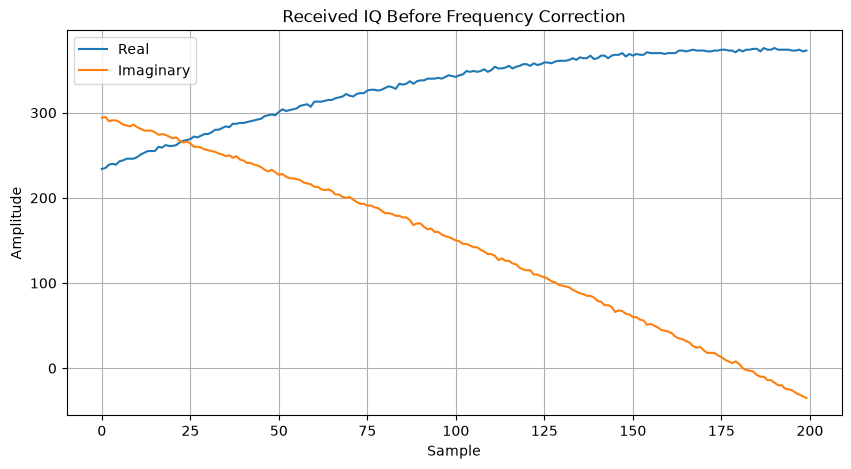

Initial received signal phase: 51.483073692897236 degrees


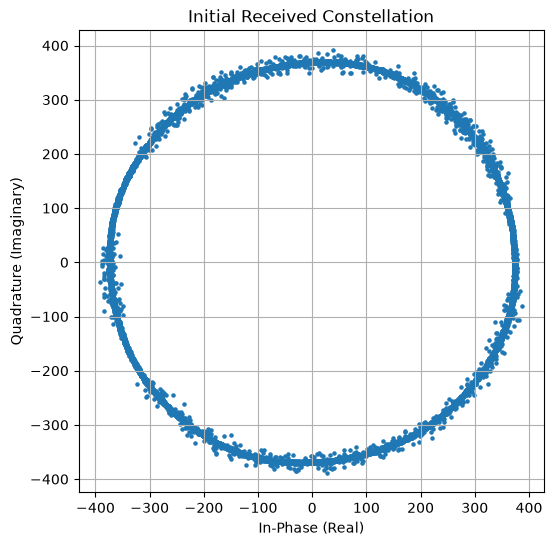

Estimated phase difference: -0.0050866794309793245 radians
Estimated frequency offset in degrees/sample: -0.2914452631311224


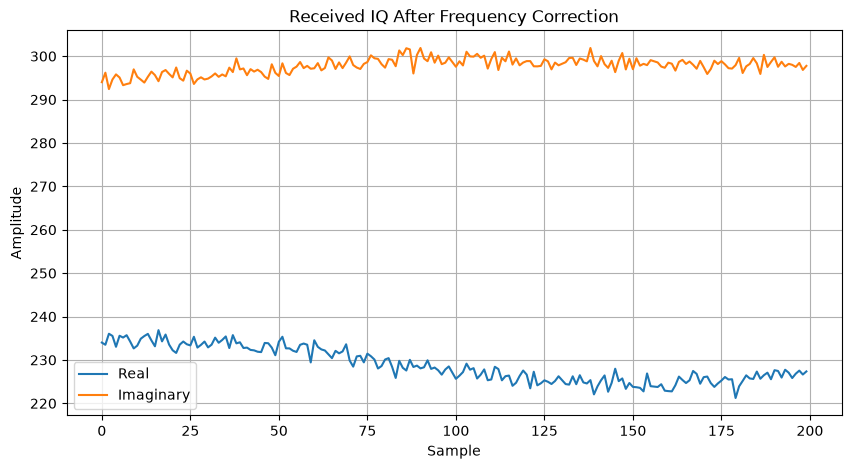

Phase after frequency correction: 51.03492525584821 degrees
Phase correction required: -51.03492525584821 degrees
Final received signal phase: 7.09028329450307e-15 degrees


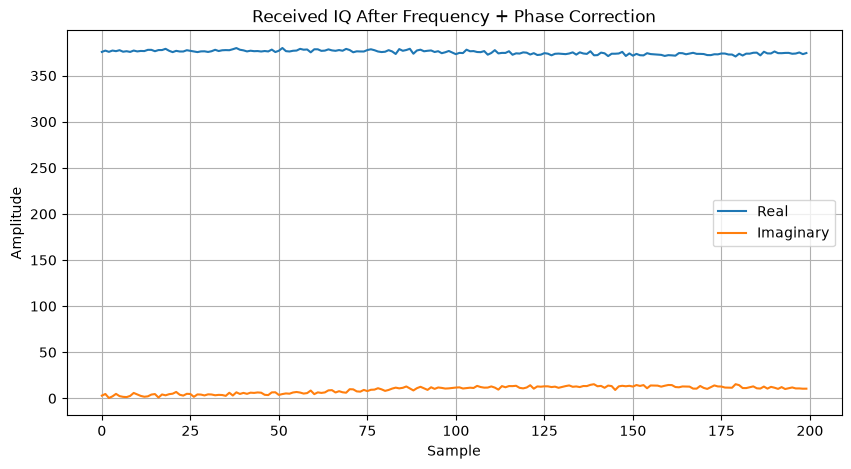

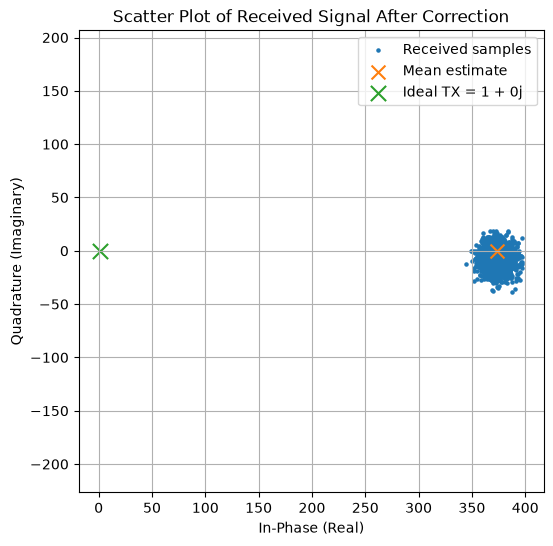

Estimated DC component: (373.3558239383894+4.620233085006476e-14j)
Estimated DC magnitude: 373.3558239383894
Estimated DC phase: 7.09028329450307e-15 degrees
Mean of isolated noise: (-5.968558980384842e-15-3.637978807091713e-16j)


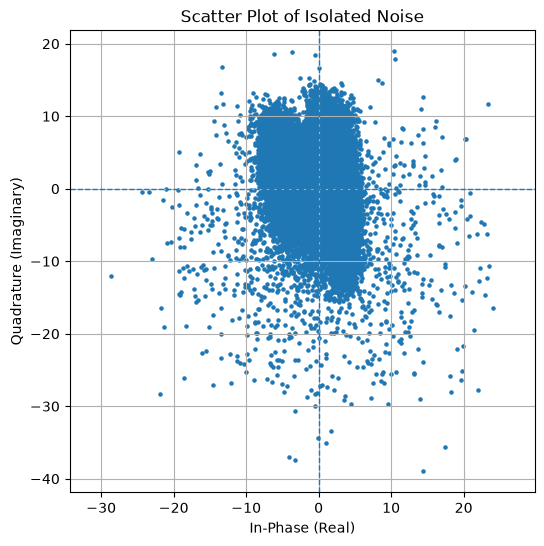

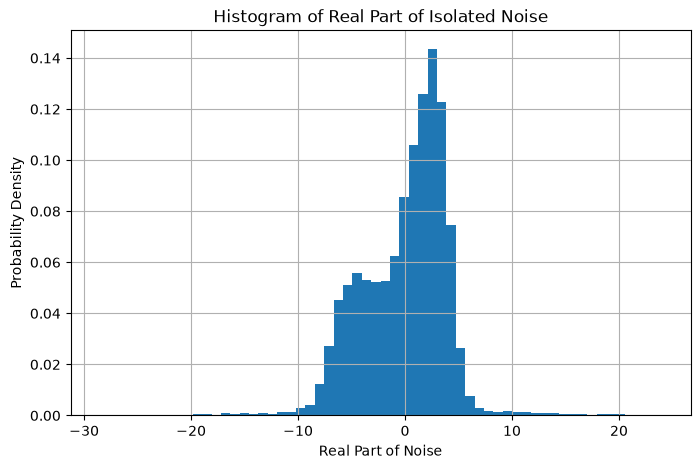

Noise variance: 54.34573128638896


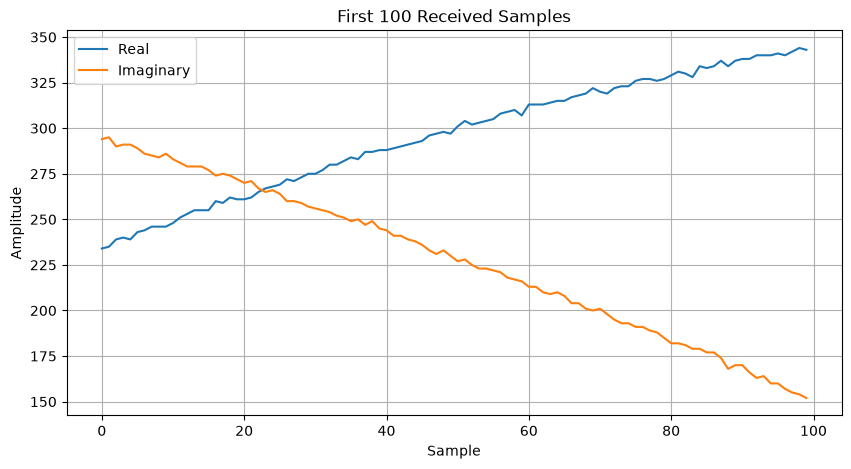

In [56]:
###################################################################
# TODO: Coarse Frequency Correction & 1D Noise Histogram
###################################################################

# 1. Place the coarse frequency correction you implemented in Lab 2 over here. Plot the received IQ before and after correction
#    (conjugate multiplication and estimation).

# Plot the received IQ before correction
plt.figure(figsize=(10, 5))
plt.plot(np.real(rx_samples_1d[:200]), label="Real")
plt.plot(np.imag(rx_samples_1d[:200]), label="Imaginary")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ Before Frequency Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Initial phase of the received signal
# ---------------------------------------------------------------

# Since frequency offset causes the signal phase to rotate with
# sample number, the first sample represents the initial phase.

initial_phase = np.angle(
    rx_samples_1d[0],
    deg=True
)

print(
    "Initial received signal phase:",
    initial_phase,
    "degrees"
)


# ---------------------------------------------------------------
# Plot initial received constellation
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_samples_1d),
    np.imag(rx_samples_1d),
    s=5
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Initial Received Constellation")
plt.grid()
plt.axis("equal")
plt.show()


# --- Remove DC offset ---

# For Task 1, the transmitter is sending:
#
# TX = 1 + 0j
#
# Therefore, we do NOT subtract the mean here.
# The mean contains the transmitted signal itself.
#
# We use the original received samples for frequency correction.

rx_dc_corrected = rx_samples_1d


# --- Coarse frequency correction using phase differentials ---

# Conjugate multiplication of consecutive samples
phase_diff = (
    rx_dc_corrected[1:]
    * np.conj(rx_dc_corrected[:-1])
)


# Estimate the average phase difference
estimated_phase = np.angle(
    np.mean(phase_diff)
)


print(
    "Estimated phase difference:",
    estimated_phase,
    "radians"
)

print(
    "Estimated frequency offset in degrees/sample:",
    np.degrees(estimated_phase)
)


# Generate sample index
n = np.arange(
    len(rx_dc_corrected)
)


# Generate frequency correction signal
correction = np.exp(
    -1j * estimated_phase * n
)


# Apply frequency correction
rx_frequency_corrected = (
    rx_dc_corrected * correction
)


# Plot the received IQ after frequency correction
plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_frequency_corrected[:200]),
    label="Real"
)

plt.plot(
    np.imag(rx_frequency_corrected[:200]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ After Frequency Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Estimate phase after frequency correction
# ---------------------------------------------------------------

phase_corrected_signal_estimate = np.mean(
    rx_frequency_corrected
)

phase_after_frequency_correction = np.angle(
    phase_corrected_signal_estimate,
    deg=True
)

print(
    "Phase after frequency correction:",
    phase_after_frequency_correction,
    "degrees"
)


# ---------------------------------------------------------------
# Phase correction
#
# Target phase = 0 degrees
# ---------------------------------------------------------------

target_phase = 0.0

phase_error = (
    target_phase
    - phase_after_frequency_correction
)

print(
    "Phase correction required:",
    phase_error,
    "degrees"
)


# Convert phase correction from degrees to radians
phase_correction = np.exp(
    1j * np.radians(phase_error)
)


# Apply phase correction
rx_corrected = (
    rx_frequency_corrected
    * phase_correction
)


# ---------------------------------------------------------------
# Calculate final phase
# ---------------------------------------------------------------

final_signal_estimate = np.mean(
    rx_corrected
)

final_phase = np.angle(
    final_signal_estimate,
    deg=True
)

print(
    "Final received signal phase:",
    final_phase,
    "degrees"
)


# ---------------------------------------------------------------
# Plot the received IQ after frequency and phase correction
# ---------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_corrected[:200]),
    label="Real"
)

plt.plot(
    np.imag(rx_corrected[:200]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ After Frequency + Phase Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Scatter plot of received signal
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_corrected),
    np.imag(rx_corrected),
    s=5,
    label="Received samples"
)


# Plot the estimated received signal
plt.scatter(
    np.real(final_signal_estimate),
    np.imag(final_signal_estimate),
    s=100,
    marker="x",
    label="Mean estimate"
)


# Plot ideal transmitted signal
plt.scatter(
    1,
    0,
    s=120,
    marker="x",
    label="Ideal TX = 1 + 0j"
)


plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Scatter Plot of Received Signal After Correction")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# 2. Write the code for subtracting the expected received signal (the '1's)
#    from your corrected samples to isolate the noise.

# The transmitter is sending:
#
# TX = 1 + 0j
#
# Therefore, after frequency and phase correction,
# the received signal contains:
#
# RX = DC signal + noise
#
# The DC component represents the received version of
# the transmitted constant signal.
#
# We estimate this DC component and subtract it
# to isolate the noise.


# ---------------------------------------------------------------
# Estimate DC component
# ---------------------------------------------------------------

dc_component = np.mean(
    rx_corrected
)

print(
    "Estimated DC component:",
    dc_component
)

print(
    "Estimated DC magnitude:",
    np.abs(dc_component)
)

print(
    "Estimated DC phase:",
    np.angle(
        dc_component,
        deg=True
    ),
    "degrees"
)


# ---------------------------------------------------------------
# Remove DC component to isolate noise
# ---------------------------------------------------------------

noise_1d = (
    rx_corrected
    - dc_component
)


# ---------------------------------------------------------------
# Check mean of isolated noise
# ---------------------------------------------------------------

noise_mean = np.mean(
    noise_1d
)

print(
    "Mean of isolated noise:",
    noise_mean
)


# ---------------------------------------------------------------
# Scatter plot of isolated noise
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(noise_1d),
    np.imag(noise_1d),
    s=5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Scatter Plot of Isolated Noise")
plt.grid()
plt.axis("equal")
plt.show()


# 3. Plot the histogram of the real part of the isolated noise along the x-axis.
#    It should resemble a Gaussian (normal) distribution.

plt.figure(figsize=(8, 5))

plt.hist(
    np.real(noise_1d),
    bins=60,
    density=True
)

plt.xlabel("Real Part of Noise")
plt.ylabel("Probability Density")
plt.title("Histogram of Real Part of Isolated Noise")
plt.grid()
plt.show()


# --- VISUALIZATION & INSIGHT TIPS ---
# TIP: Print the variance (np.var) of your isolated noise. Does the number seem reasonable?

print(
    "Noise variance:",
    np.var(noise_1d)
)


# TIP: Plot the first 100 samples of the received signal against time (plt.plot).
#      You should visually see the noise "riding" on top of the constant DC level.

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_samples_1d[:100]),
    label="Real"
)

plt.plot(
    np.imag(rx_samples_1d[:100]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("First 100 Received Samples")
plt.legend()
plt.grid()
plt.show()

> **Stop and Ponder:** Think about the frequency correction step you just performed. Why is it absolutely crucial to correct the frequency offset *before* attempting to isolate and plot the noise? What would your histogram look like if the frequency offset was still present?

### Complex Noise (2D)
Now we will repeat the experiment but transmit $1+1j$ to observe noise in the complex plane.
Transmit the complex symbol `1 + 1j` scaled appropriately.

**Instructions & Questions:**
1. Strip the DC offset and perform coarse frequency correction.
2. **Intermediate Plot:** Before subtracting the signal mean, plot the locked complex constellation scatter plot. Overlay the mean estimate as a prominent red marker.
3. **Final Plot:** Subtract the mean to center the cluster at (0,0) and generate a 2D histogram (heatmap) of the complex noise.

In [58]:
'''
# --- Transmit 1+1j (Complex fixed points) ---
tx_symbols_2d = (np.ones(10000) + 1j*np.ones(10000)).astype(np.complex64) * (tx_scale / np.sqrt(2))
tx_sdr.tx_cyclic_buffer = True #[cite: 1]
tx_sdr.tx(tx_symbols_2d)
time.sleep(0.5)
'''

# Receive
rx_samples_2d = rx_sdr.rx()
# tx_sdr.tx_destroy_buffer()
print(rx_samples_2d[50:80])

[-102.-364.j -102.-364.j -105.-363.j -106.-360.j -106.-361.j -108.-360.j
 -109.-362.j -112.-360.j -112.-358.j -116.-357.j -117.-359.j -122.-358.j
 -123.-356.j -124.-356.j -128.-356.j -128.-354.j -129.-356.j -132.-357.j
 -133.-355.j -133.-354.j -137.-352.j -139.-354.j -139.-351.j -139.-351.j
 -142.-350.j -146.-349.j -149.-347.j -150.-347.j -151.-346.j -151.-345.j]


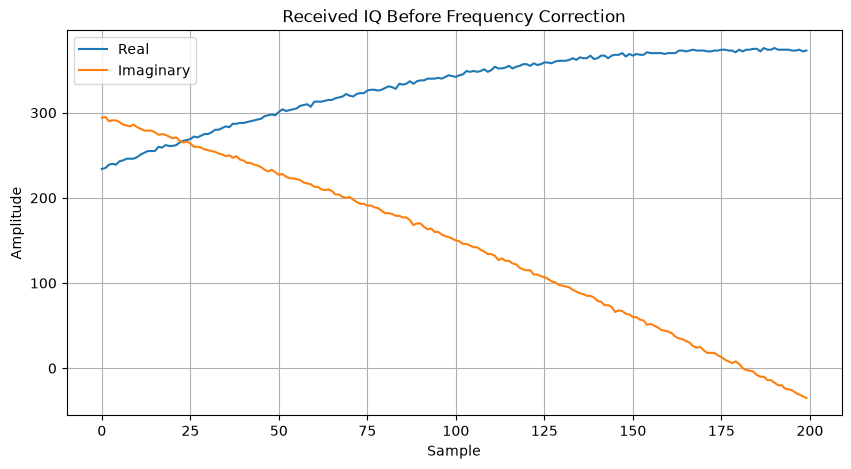

Initial received signal phase: 17.190029867461693 degrees


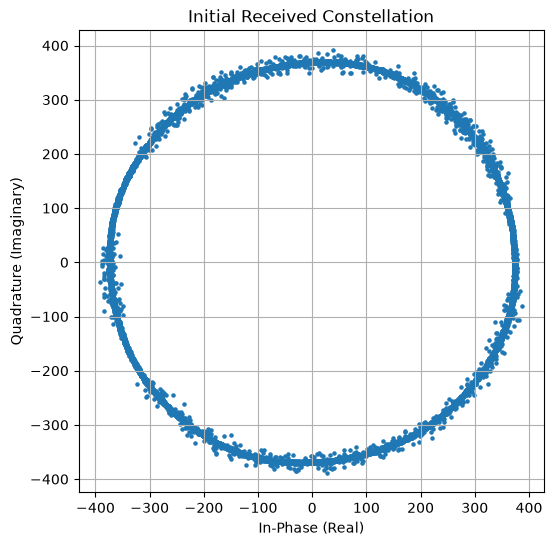

Estimated phase difference: -0.005086690006954448
Estimated frequency offset in degrees/sample: -0.29144586908986125


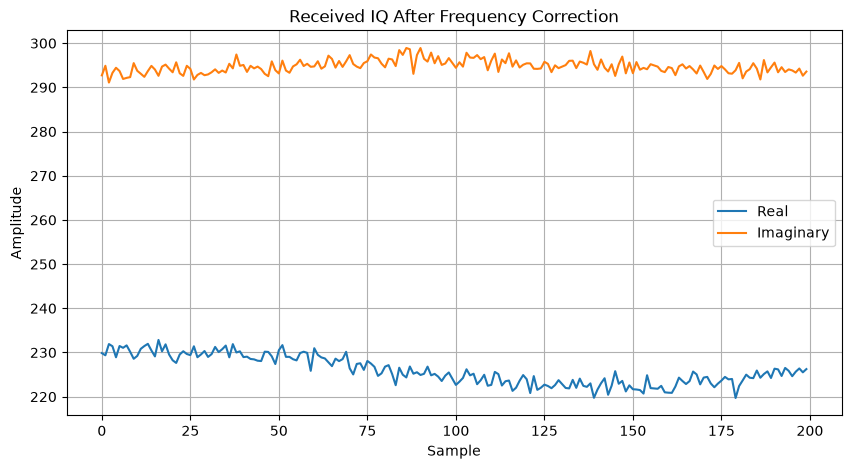

Phase after frequency correction: 51.04092665466139 degrees
Phase correction required: -6.040926654661391 degrees
Final received signal phase: 45.0 degrees


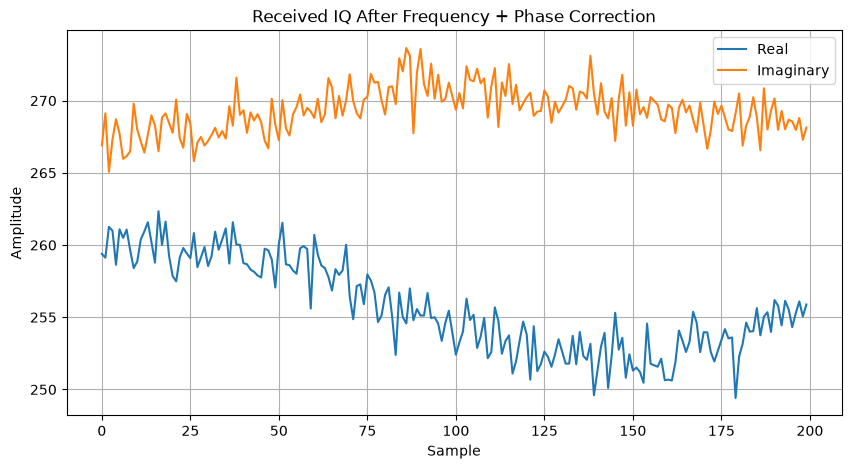

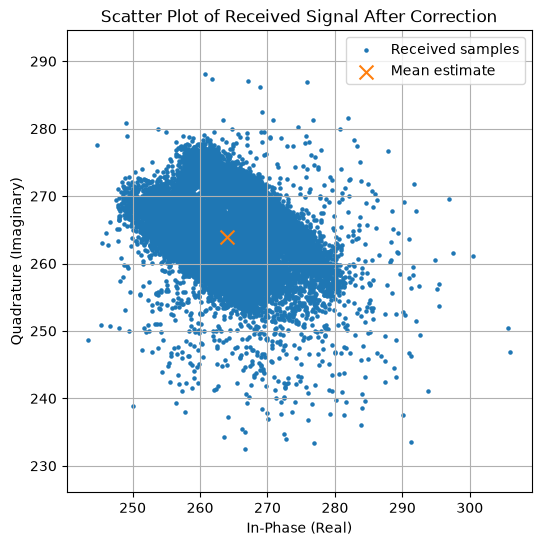

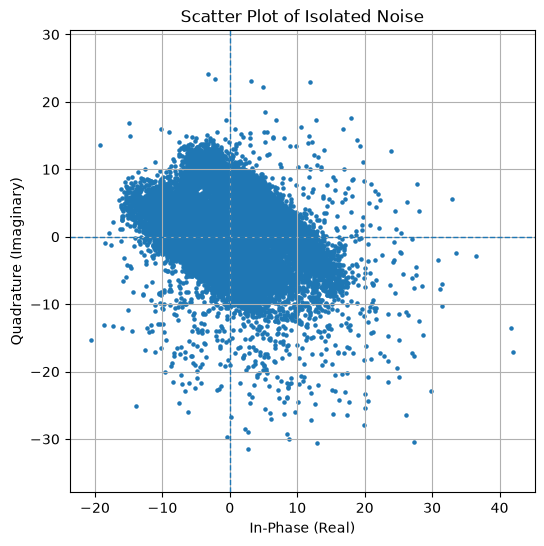

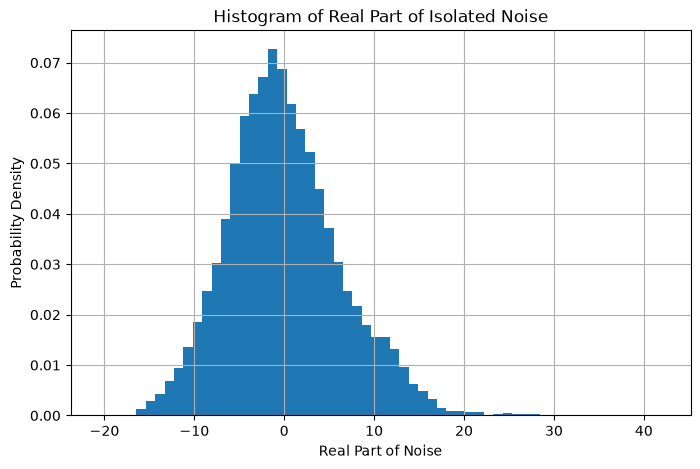

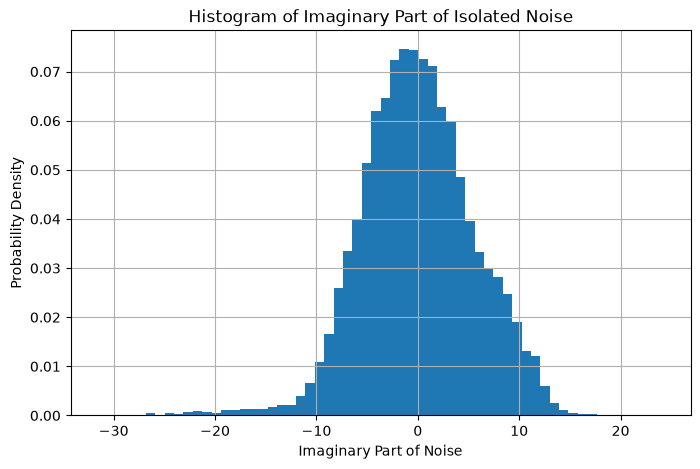

Noise variance: 71.35805857101458
Real noise variance: 40.1826334280635
Imaginary noise variance: 31.1754251429511
Noise variance: 71.35805857101458


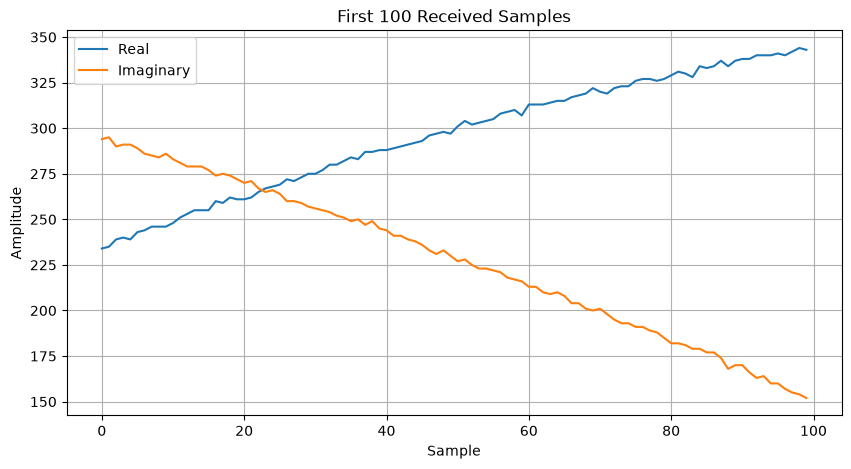

In [61]:
###################################################################
# TODO: Coarse Frequency Correction & 1D Noise Histogram
###################################################################

# 1. Place the coarse frequency correction you implemented in Lab 2 over here. Plot the received IQ before and after correction
#    (conjugate multiplication and estimation).

# Plot the received IQ before correction
plt.figure(figsize=(10, 5))
plt.plot(np.real(rx_samples_1d[:200]), label="Real")
plt.plot(np.imag(rx_samples_1d[:200]), label="Imaginary")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ Before Frequency Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Initial phase of the received signal
# ---------------------------------------------------------------

initial_signal_estimate = np.mean(rx_samples_1d)

initial_phase = np.angle(initial_signal_estimate, deg=True)

print("Initial received signal phase:", initial_phase, "degrees")


# ---------------------------------------------------------------
# Plot initial received constellation
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_samples_1d),
    np.imag(rx_samples_1d),
    s=5
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Initial Received Constellation")
plt.grid()
plt.axis("equal")
plt.show()


# --- Remove DC offset ---
rx_dc_corrected = rx_samples_1d - np.mean(rx_samples_1d)


# --- Coarse frequency correction using phase differentials ---

# Conjugate multiplication of consecutive samples
phase_diff = rx_dc_corrected[1:] * np.conj(rx_dc_corrected[:-1])


# Estimate the average phase difference
estimated_phase = np.angle(np.mean(phase_diff))


print("Estimated phase difference:", estimated_phase)
print(
    "Estimated frequency offset in degrees/sample:",
    np.degrees(estimated_phase)
)


# Generate sample index
n = np.arange(len(rx_dc_corrected))


# Generate frequency correction signal
correction = np.exp(-1j * estimated_phase * n)


# Apply frequency correction
rx_frequency_corrected = rx_dc_corrected * correction


# Plot the received IQ after frequency correction
plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_frequency_corrected[:200]),
    label="Real"
)

plt.plot(
    np.imag(rx_frequency_corrected[:200]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ After Frequency Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Estimate phase after frequency correction
# ---------------------------------------------------------------

phase_corrected_signal_estimate = np.mean(rx_frequency_corrected)

phase_after_frequency_correction = np.angle(
    phase_corrected_signal_estimate,
    deg=True
)

print(
    "Phase after frequency correction:",
    phase_after_frequency_correction,
    "degrees"
)


# ---------------------------------------------------------------
# Phase correction
#
# Target phase = +45 degrees
# ---------------------------------------------------------------

target_phase = 45.0

phase_error = target_phase - phase_after_frequency_correction

print("Phase correction required:", phase_error, "degrees")


# Convert phase correction from degrees to radians
phase_correction = np.exp(
    1j * np.radians(phase_error)
)


# Apply phase correction
rx_corrected = rx_frequency_corrected * phase_correction


# ---------------------------------------------------------------
# Calculate final phase
# ---------------------------------------------------------------

final_signal_estimate = np.mean(rx_corrected)

final_phase = np.angle(
    final_signal_estimate,
    deg=True
)

print("Final received signal phase:", final_phase, "degrees")


# ---------------------------------------------------------------
# Plot the received IQ after frequency and phase correction
# ---------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_corrected[:200]),
    label="Real"
)

plt.plot(
    np.imag(rx_corrected[:200]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Received IQ After Frequency + Phase Correction")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Scatter plot of received signal
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(rx_corrected),
    np.imag(rx_corrected),
    s=5,
    label="Received samples"
)


# Plot the estimated received signal
plt.scatter(
    np.real(final_signal_estimate),
    np.imag(final_signal_estimate),
    s=100,
    marker="x",
    label="Mean estimate"
)


plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Scatter Plot of Received Signal After Correction")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# 2. Write the code for subtracting the expected received signal (the '1's)
#    from your corrected samples to isolate the noise.

# Estimate the received signal rather than assuming
# that its amplitude is exactly 1.

signal_estimate = np.mean(rx_corrected)


# Subtract the estimated received signal
noise_1d = rx_corrected - signal_estimate


# ---------------------------------------------------------------
# Scatter plot of isolated noise
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    np.real(noise_1d),
    np.imag(noise_1d),
    s=5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Scatter Plot of Isolated Noise")
plt.grid()
plt.axis("equal")
plt.show()


# 3. Plot the histogram of the real part of the isolated noise along the x-axis.
#    It should resemble a Gaussian (normal) distribution.

# ---------------------------------------------------------------
# Histogram of isolated noise
# ---------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    np.real(noise_1d),
    bins=60,
    density=True
)

plt.xlabel("Real Part of Noise")
plt.ylabel("Probability Density")
plt.title("Histogram of Real Part of Isolated Noise")
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Histogram of imaginary part of isolated noise
# ---------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    np.imag(noise_1d),
    bins=60,
    density=True
)

plt.xlabel("Imaginary Part of Noise")
plt.ylabel("Probability Density")
plt.title("Histogram of Imaginary Part of Isolated Noise")
plt.grid()
plt.show()


# ---------------------------------------------------------------
# Noise variance
# ---------------------------------------------------------------

print("Noise variance:", np.var(noise_1d))
print("Real noise variance:", np.var(np.real(noise_1d)))
print("Imaginary noise variance:", np.var(np.imag(noise_1d)))


# --- VISUALIZATION & INSIGHT TIPS ---
# TIP: Print the variance (np.var) of your isolated noise. Does the number seem reasonable?

print("Noise variance:", np.var(noise_1d))


# TIP: Plot the first 100 samples of the received signal against time (plt.plot).
#      You should visually see the noise "riding" on top of the constant DC level.

plt.figure(figsize=(10, 5))

plt.plot(
    np.real(rx_samples_1d[:100]),
    label="Real"
)

plt.plot(
    np.imag(rx_samples_1d[:100]),
    label="Imaginary"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("First 100 Received Samples")
plt.legend()
plt.grid()
plt.show()

> **Stop and Ponder:** If your 2D histogram or scatter plot turned out to be strictly elliptical (stretched out along one axis) instead of circular, what physical imperfections in the SDR hardware's I and Q channels might cause this?

## Task 2: Modulation Schemes and Decoding Intuition

*Note: This task is purely Python-based. No SDR hardware is required.*

In this task, we explore the mathematics of how we represent digital information and what happens when the types of noise you isolated in Task 1 corrupt those signals.

### Modulation and Noise
**BPSK (Binary Phase Shift Keying):** Symbols are distributed on a 1D line. The transmitted symbol $s$ is either positive or negative based on the signal energy $E_s$.
$$s \in \{+\sqrt{E_s}, -\sqrt{E_s}\}$$

**4-QAM (Quadrature Amplitude Modulation):** Symbols are distributed in a 2D complex plane.
$$s \in \{\pm \sqrt{E_s/2} \pm j\sqrt{E_s/2}\}$$

**Additive White Gaussian Noise (AWGN):** When a signal travels through a channel, it picks up noise. The received signal $y$ is the transmitted symbol $s$ plus noise $w$:
$$y = s + w$$

For 1D signals (like BPSK), the noise is purely Real Gaussian Noise (GN):
$$w \sim \mathbb{N}(0, \sigma^2)$$

For 2D signals (like 4-QAM), the noise is Complex Standard Circular Gaussian Noise (CSCGN). This is essentially a 2D Gaussian where the real and imaginary parts are independent:
$$w \sim \mathbb{CN}(0, \sigma^2) = \mathbb{N}(0, \sigma^2/2) + j\mathbb{N}(0, \sigma^2/2)$$

### Your Task
Suppose you receive a corrupted symbol $y$. If you know the transmitted symbol was chosen from a specific set of fixed points (like the BPSK or 4-QAM constellations), and the noise acts as a random, symmetric "cloud" or "nudge" in any direction, how would you intuitively decide which symbol was originally sent?

*Hint: Think about the geometry of the situation. If you are standing at point $y$, which constellation point makes the most logical sense to guess based on distance? Mathematically, if your ideal constellation points are $s_i$, you want to find the point that minimizes the Euclidean distance to $y$: $\arg\min_{s_i} |y - s_i|$. This intuitive geometric approach is exactly equivalent to **Maximum Likelihood (ML)** decoding for AWGN channels!*

**Implementation:** (Generate intermediate plots for visualization of each step)
1. Write code to generate arrays of random BPSK and 4-QAM symbols.
2. Add GN to your BPSK symbols and CSCGN to your 4-QAM symbols.
3. Implement your intuitive nearest-neighbor decoding logic to guess the original symbols from the noisy received ones.
4. Calculate the **Symbol Error Rate (SER)** (Number of incorrect guesses / Total symbols).
5. Test how the SER changes with varying **Signal-to-Noise Ratio (SNR)**. Fix your signal power (e.g., $E_s = 1$) and write a loop to sweep through a range of noise variances ($\sigma^2$) or visa-versa(Try both methods). Plot the calculated error rate on the y-axis against the noise variance or SNR on the x-axis to visualize the performance degradation.

> **Stop and Ponder:** As you artificially increase the noise power (making the noise clouds wider and wider), the distinct clusters of points will begin to overlap and merge. At what point does your intuitive geometric decoding logic start to fail? Is it a gradual increase in errors, or a sudden total failure?

BPSK Symbol Error Rate: 0.0006


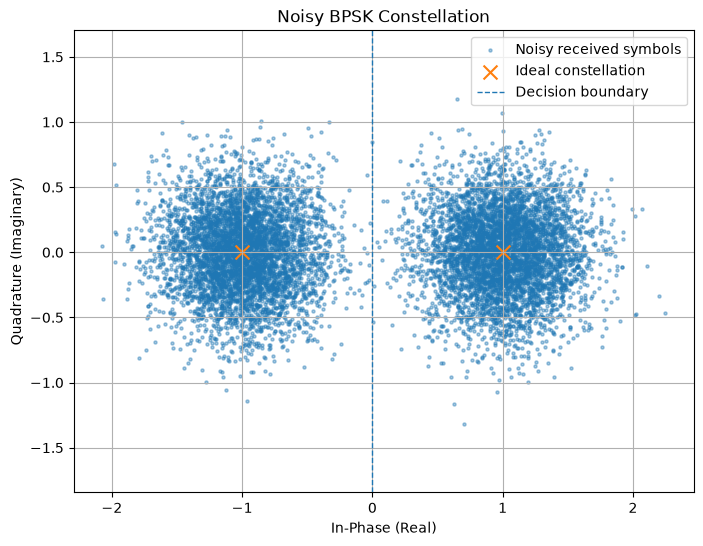

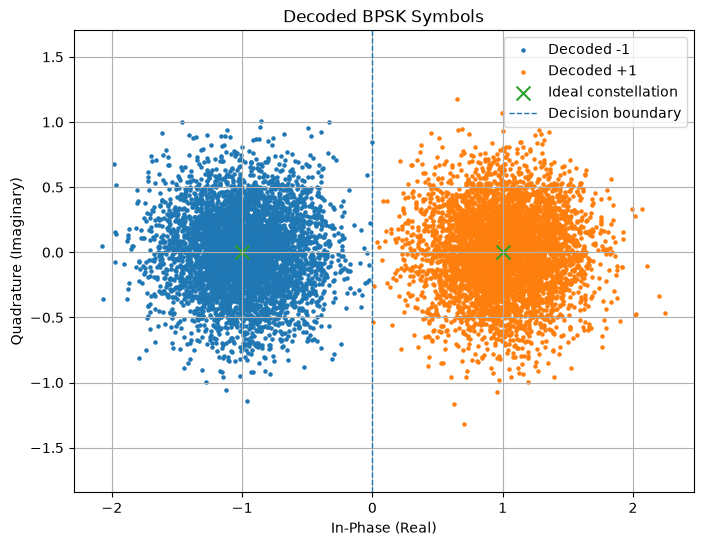

4-QAM Symbol Error Rate: 0.0249


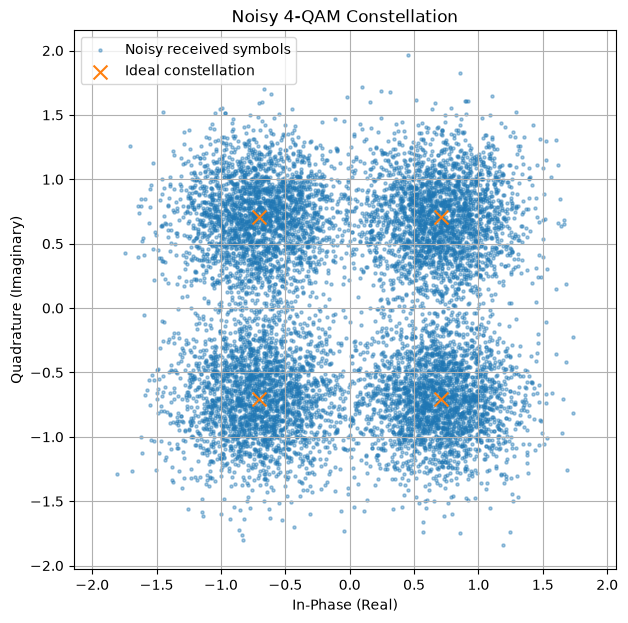

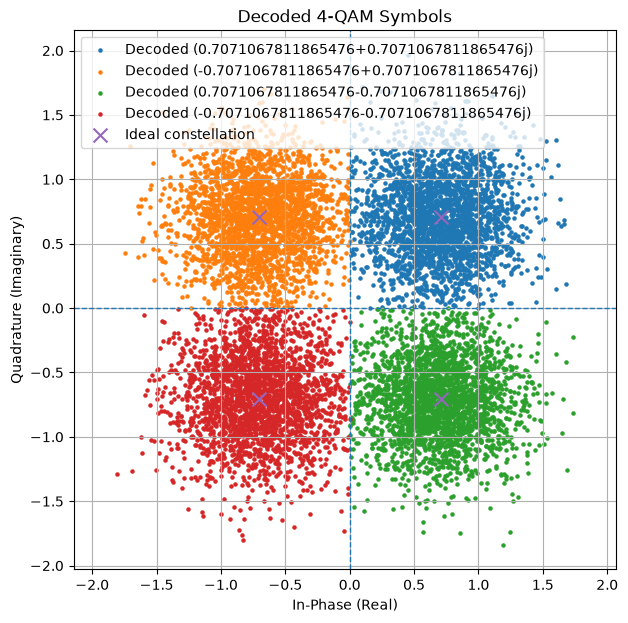

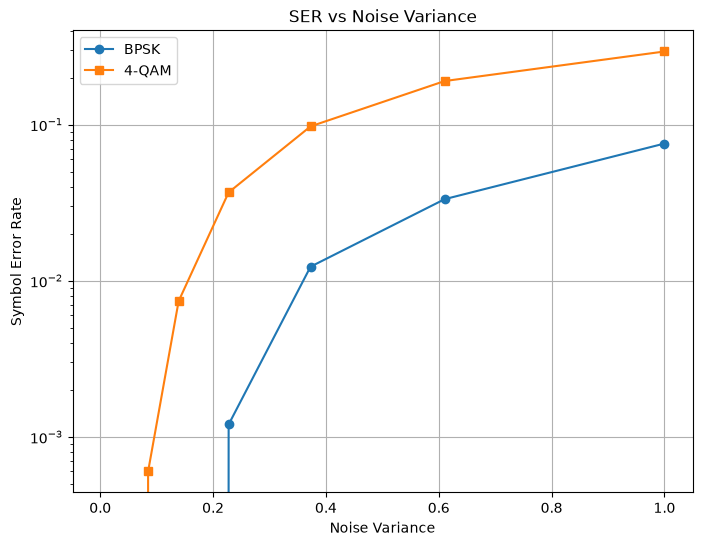

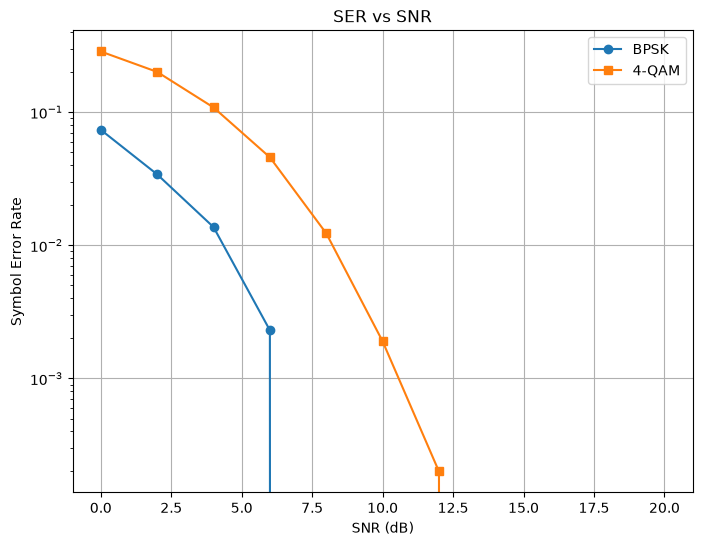

In [15]:
###################################################################
# TODO: Simulation, Noise Addition, and Decoding
###################################################################

# Write your Task 2 implementation here.

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------

num_symbols = 10000
Es = 1.0


# ===============================================================
# BPSK
# ===============================================================

# Generate random BPSK symbols

bits_bpsk = np.random.randint(0, 2, num_symbols)

bpsk_symbols = 2 * bits_bpsk - 1


# ---------------------------------------------------------------
# BPSK constellation
# ---------------------------------------------------------------

bpsk_constellation = np.array([
    -1 + 0j,
    1 + 0j
])


# ---------------------------------------------------------------
# Add Gaussian noise
# ---------------------------------------------------------------

noise_variance_bpsk = 0.2

# Generate real and imaginary Gaussian noise components

noise_bpsk_real = np.sqrt(
    noise_variance_bpsk / 2
) * np.random.randn(num_symbols)

noise_bpsk_imag = np.sqrt(
    noise_variance_bpsk / 2
) * np.random.randn(num_symbols)

# Combine real and imaginary noise components

noise_bpsk = (
    noise_bpsk_real
    + 1j * noise_bpsk_imag
)

# Received BPSK signal

rx_bpsk = bpsk_symbols + noise_bpsk


# ---------------------------------------------------------------
# BPSK decoding using minimum distance
# ---------------------------------------------------------------

decoded_bpsk = np.zeros(
    num_symbols,
    dtype=complex
)

for i in range(num_symbols):

    distances = np.abs(
        rx_bpsk[i] - bpsk_constellation
    )

    decoded_bpsk[i] = bpsk_constellation[
        np.argmin(distances)
    ]


# ---------------------------------------------------------------
# BPSK SER
# ---------------------------------------------------------------

bpsk_errors = np.sum(
    decoded_bpsk != bpsk_symbols
)

bpsk_ser = bpsk_errors / num_symbols

print("BPSK Symbol Error Rate:", bpsk_ser)


# ---------------------------------------------------------------
# Plot noisy BPSK symbols
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    np.real(rx_bpsk),
    np.imag(rx_bpsk),
    s=5,
    alpha=0.4,
    label="Noisy received symbols"
)

plt.scatter(
    np.real(bpsk_constellation),
    np.imag(bpsk_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="Decision boundary"
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Noisy BPSK Constellation")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ---------------------------------------------------------------
# Plot decoded BPSK symbols
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Points decoded as -1

mask_minus = decoded_bpsk == -1

plt.scatter(
    np.real(rx_bpsk[mask_minus]),
    np.imag(rx_bpsk[mask_minus]),
    s=5,
    label="Decoded -1"
)


# Points decoded as +1

mask_plus = decoded_bpsk == 1

plt.scatter(
    np.real(rx_bpsk[mask_plus]),
    np.imag(rx_bpsk[mask_plus]),
    s=5,
    label="Decoded +1"
)


# Plot ideal constellation points

plt.scatter(
    np.real(bpsk_constellation),
    np.imag(bpsk_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)


# Decision boundary

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="Decision boundary"
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Decoded BPSK Symbols")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ===============================================================
# 4-QAM
# ===============================================================

# Generate 4-QAM symbols

qam_level = np.sqrt(Es / 2)

real_bits = np.random.randint(
    0,
    2,
    num_symbols
)

imag_bits = np.random.randint(
    0,
    2,
    num_symbols
)


real_part = 2 * real_bits - 1
imag_part = 2 * imag_bits - 1


qam_symbols = qam_level * (
    real_part + 1j * imag_part
)


# ---------------------------------------------------------------
# 4-QAM constellation
# ---------------------------------------------------------------

qam_constellation = np.array([
    qam_level + 1j * qam_level,
    -qam_level + 1j * qam_level,
    qam_level - 1j * qam_level,
    -qam_level - 1j * qam_level
])


# ---------------------------------------------------------------
# Add Complex Standard Circular Gaussian Noise
# ---------------------------------------------------------------

noise_variance_qam = 0.2

noise_real = np.sqrt(
    noise_variance_qam / 2
) * np.random.randn(num_symbols)

noise_imag = np.sqrt(
    noise_variance_qam / 2
) * np.random.randn(num_symbols)


noise_qam = noise_real + 1j * noise_imag

rx_qam = qam_symbols + noise_qam


# ---------------------------------------------------------------
# 4-QAM decoding using minimum geometric distance
# ---------------------------------------------------------------

decoded_qam = np.zeros(
    num_symbols,
    dtype=complex
)

for i in range(num_symbols):

    distances = np.abs(
        rx_qam[i] - qam_constellation
    )

    decoded_qam[i] = qam_constellation[
        np.argmin(distances)
    ]


# ---------------------------------------------------------------
# 4-QAM SER
# ---------------------------------------------------------------

qam_errors = np.sum(
    decoded_qam != qam_symbols
)

qam_ser = qam_errors / num_symbols

print("4-QAM Symbol Error Rate:", qam_ser)


# ---------------------------------------------------------------
# Plot noisy 4-QAM symbols
# ---------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    np.real(rx_qam),
    np.imag(rx_qam),
    s=5,
    alpha=0.4,
    label="Noisy received symbols"
)

plt.scatter(
    np.real(qam_constellation),
    np.imag(qam_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Noisy 4-QAM Constellation")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ---------------------------------------------------------------
# Plot decoded 4-QAM symbols
# ---------------------------------------------------------------

plt.figure(figsize=(7, 7))

for symbol in qam_constellation:

    mask = decoded_qam == symbol

    plt.scatter(
        np.real(rx_qam[mask]),
        np.imag(rx_qam[mask]),
        s=5,
        label=f"Decoded {symbol}"
    )


plt.scatter(
    np.real(qam_constellation),
    np.imag(qam_constellation),
    marker="x",
    s=100,
    label="Ideal constellation"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("In-Phase (Real)")
plt.ylabel("Quadrature (Imaginary)")
plt.title("Decoded 4-QAM Symbols")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# ---------------------------------------------------------------
# SER vs Noise Variance
# ---------------------------------------------------------------

noise_variances = np.logspace(
    -3,
    0,
    15
)

ser_bpsk = []
ser_qam = []


for variance in noise_variances:

    # BPSK

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise = noise_real + 1j * noise_imag

    rx = bpsk_symbols + noise


    # BPSK nearest-neighbor decoding

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - bpsk_constellation
        )

        decoded[i] = bpsk_constellation[
            np.argmin(distances)
        ]


    errors = np.sum(
        decoded != bpsk_symbols
    )

    ser_bpsk.append(
        errors / num_symbols
    )


    # 4-QAM

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise = noise_real + 1j * noise_imag

    rx = qam_symbols + noise

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - qam_constellation
        )

        decoded[i] = qam_constellation[
            np.argmin(distances)
        ]

    errors = np.sum(
        decoded != qam_symbols
    )

    ser_qam.append(
        errors / num_symbols
    )


# ---------------------------------------------------------------
# Plot SER vs Noise Variance
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.semilogy(
    noise_variances,
    ser_bpsk,
    marker="o",
    label="BPSK"
)

plt.semilogy(
    noise_variances,
    ser_qam,
    marker="s",
    label="4-QAM"
)

plt.xlabel("Noise Variance")
plt.ylabel("Symbol Error Rate")
plt.title("SER vs Noise Variance")
plt.legend()
plt.grid()
plt.show()


# ---------------------------------------------------------------
# SER vs SNR
# ---------------------------------------------------------------

snr_db = np.arange(
    0,
    21,
    2
)

ser_bpsk_snr = []
ser_qam_snr = []


for snr in snr_db:

    variance = Es / (
        10 ** (snr / 10)
    )


    # BPSK

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise = noise_real + 1j * noise_imag

    rx = bpsk_symbols + noise


    # BPSK nearest-neighbor decoding

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - bpsk_constellation
        )

        decoded[i] = bpsk_constellation[
            np.argmin(distances)
        ]


    errors = np.sum(
        decoded != bpsk_symbols
    )

    ser_bpsk_snr.append(
        errors / num_symbols
    )


    # 4-QAM

    noise_real = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    noise_imag = np.sqrt(
        variance / 2
    ) * np.random.randn(num_symbols)

    rx = qam_symbols + (
        noise_real + 1j * noise_imag
    )

    decoded = np.zeros(
        num_symbols,
        dtype=complex
    )

    for i in range(num_symbols):

        distances = np.abs(
            rx[i] - qam_constellation
        )

        decoded[i] = qam_constellation[
            np.argmin(distances)
        ]

    errors = np.sum(
        decoded != qam_symbols
    )

    ser_qam_snr.append(
        errors / num_symbols
    )


# ---------------------------------------------------------------
# Plot SER vs SNR
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.semilogy(
    snr_db,
    ser_bpsk_snr,
    marker="o",
    label="BPSK"
)

plt.semilogy(
    snr_db,
    ser_qam_snr,
    marker="s",
    label="4-QAM"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Symbol Error Rate")
plt.title("SER vs SNR")
plt.legend()
plt.grid()
plt.show()


# --- VISUALIZATION & INSIGHT TIPS ---
# TIP: To verify your decoder works, plot your noisy 4-QAM symbols using a scatter plot.
#      Color-code the received points based on what your decoder *thinks* they are
#      (e.g., color points decoded as +1+1j red, -1+1j blue, etc.).
#      You should see clear decision boundaries form along the axes!
# TIP: Ensure you plot the final SER vs. Variance (or SNR) on a logarithmic y-axis
#      (plt.semilogy) to better visualize the steep drop-off in errors.

## Task: End-to-End BPSK over SDR

Now that you understand noise modeling and basic decision-making mathematically, try putting it all together on the hardware! In this bonus task, your goal is to implement a full BPSK transmission and reception pipeline over the air.

**The Flow:**
1. **Generate Symbols:** Create an array of random BPSK symbols (e.g., sequence of `+1`s and `-1`s).
2. **Transmit:** Scale them properly and send them through the `tx_sdr`.
3. **Receive:** Capture the raw samples via `rx_sdr`.
4. **Process:** Apply your coarse frequency correction. This is vital to stop the constellation from spinning in the complex plane so you can actually read the phase!
5. **Demodulate:** Extract the real part of the corrected signal and use the geometric intuition you developed in Task 2 to decode the received samples back into the original bits.

*(No code template is provided for this—use the modular pieces you've built in Labs 2 and 3 to construct the pipeline!)*

## Final Lab Questions

Please answer the following questions based on your observations in this lab:

1. **Noise Distributions:** What is the fundamental difference between standard real Gaussian noise (GN) and complex standard circular Gaussian noise (CSCGN)? How did you visually verify this difference in Task 1?
2. **Hardware Impact:** How did the variance of your isolated noise in Task 1 change as you adjusted the SDR's receiver gain (`rx_hardwaregain_chan0`)? Why does this happen?
3. **Decoding Logic:** In Task 2, why is the minimum geometric distance (Maximum Likelihood) rule the most logical choice for decoding symbols in the presence of Additive White Gaussian Noise? What assumption are we making about the noise cloud for this rule to be optimal?
4. **Simulation vs. Reality:** What unique challenges would you face when moving from the purely mathematical Python simulation in Task 2 to the physical hardware in the Bonus Task? Name at least one impairment the real hardware introduces that the simple $y = s + w$ equation does not account for.